<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()

{}

In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kushasabzevari/handwritten-persian-numerals")
print(path)

100%|██████████| 73.1k/73.1k [00:00<00:00, 44.3MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/kushasabzevari/handwritten-persian-numerals/versions/1


In [ ]:
import os

print(os.listdir(path))

['train.csv', 'test.csv']


In [ ]:
import pandas as pd

df = pd.read_csv(path + "/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.sample(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
1234,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
629,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
585,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
499,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1954,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
541,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
550,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
926,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1611,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(2000, 785)

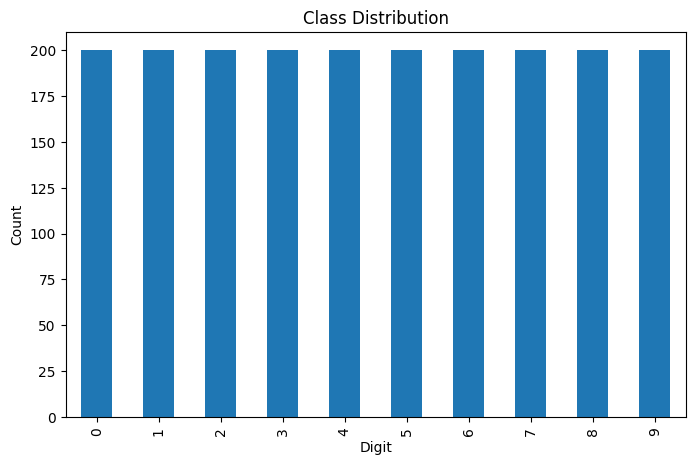

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(8,5))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

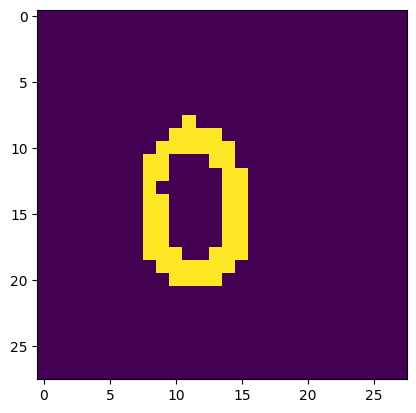

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[1,1:].values.reshape(28,28))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('label',axis=1),df['label'],test_size=0.2,random_state=42)


In [ ]:
x_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
1860,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
353,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1333,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
905,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1289,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1284,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
261,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
pca=PCA(n_components=784)
x_train=pca.fit_transform(x_train)
x_test=pca.transform(x_test)

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)


KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.715


In [ ]:
for i in range(1,785):
  pca=PCA(n_components=i)
  x_train_trf=pca.fit_transform(x_train)
  x_test_trf=pca.transform(x_test)

  knn=KNeighborsClassifier(n_neighbors=5)
  knn.fit(x_train_trf,y_train)

  y_pred=knn.predict(x_test_trf)
  accuracy=accuracy_score(y_test,y_pred)
  print("Accuracy:",accuracy)


Accuracy: 0.185
Accuracy: 0.2925
Accuracy: 0.3775
Accuracy: 0.48
Accuracy: 0.5375
Accuracy: 0.56
Accuracy: 0.63
Accuracy: 0.6375
Accuracy: 0.665
Accuracy: 0.665
Accuracy: 0.675
Accuracy: 0.6975
Accuracy: 0.6975
Accuracy: 0.7
Accuracy: 0.7175
Accuracy: 0.7325
Accuracy: 0.7475
Accuracy: 0.7575
Accuracy: 0.755
Accuracy: 0.75
Accuracy: 0.76
Accuracy: 0.7675
Accuracy: 0.77
Accuracy: 0.775
Accuracy: 0.775
Accuracy: 0.78
Accuracy: 0.7725
Accuracy: 0.7625
Accuracy: 0.7775
Accuracy: 0.78
Accuracy: 0.775
Accuracy: 0.7625
Accuracy: 0.755
Accuracy: 0.7675
Accuracy: 0.775
Accuracy: 0.7875
Accuracy: 0.785
Accuracy: 0.8
Accuracy: 0.8025
Accuracy: 0.8
Accuracy: 0.8075
Accuracy: 0.805
Accuracy: 0.81
Accuracy: 0.82
Accuracy: 0.82
Accuracy: 0.82
Accuracy: 0.825
Accuracy: 0.825
Accuracy: 0.8225
Accuracy: 0.83
Accuracy: 0.84
Accuracy: 0.825
Accuracy: 0.8275
Accuracy: 0.83
Accuracy: 0.83
Accuracy: 0.8225
Accuracy: 0.8225
Accuracy: 0.8275
Accuracy: 0.82
Accuracy: 0.8175
Accuracy: 0.8175
Accuracy: 0.8175
Accu

It appears the PCA object was re-initialized in the previous loop and left in an unfitted state after the `KeyboardInterrupt`. To correctly access `explained_variance_ratio_`, we need to re-run the data preprocessing steps and then fit a new PCA model.

In [ ]:
# Re-run train-test split to reset x_train and x_test to their original state
x_train,x_test,y_train,y_test=train_test_split(df.drop('label',axis=1),df['label'],test_size=0.2,random_state=42)


In [ ]:
# Re-run StandardScaler to scale the data
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)


In [ ]:
# Fit a new PCA model and display explained_variance_ratio_
pca_new=PCA(n_components=784)
x_train_pca=pca_new.fit_transform(x_train_scaled)
x_test_pca=pca_new.transform(x_test_scaled)

print("Explained Variance Ratio:")
display(pca_new.explained_variance_ratio_)

Explained Variance Ratio:


array([4.84892287e-02, 3.72805023e-02, 2.79868552e-02, 2.76050866e-02,
       2.45234056e-02, 2.16905791e-02, 2.05621643e-02, 1.92836859e-02,
       1.84029498e-02, 1.71647883e-02, 1.65399409e-02, 1.59303194e-02,
       1.45487931e-02, 1.42853946e-02, 1.31848672e-02, 1.27995327e-02,
       1.25797154e-02, 1.16587508e-02, 1.09552803e-02, 1.06504910e-02,
       1.03208284e-02, 9.88077658e-03, 9.66601802e-03, 9.30596270e-03,
       8.93861814e-03, 8.75719881e-03, 8.64402505e-03, 8.26422121e-03,
       8.00841430e-03, 7.94102490e-03, 7.66223089e-03, 7.40775712e-03,
       7.37807546e-03, 7.03646481e-03, 7.00021562e-03, 6.70057876e-03,
       6.62587919e-03, 6.54001376e-03, 6.33422576e-03, 6.21864042e-03,
       6.19960092e-03, 6.11487582e-03, 5.94284889e-03, 5.70626100e-03,
       5.60814118e-03, 5.36761703e-03, 5.32362814e-03, 5.24781156e-03,
       5.11358122e-03, 5.07301963e-03, 4.95161123e-03, 4.83650300e-03,
       4.76913234e-03, 4.73617910e-03, 4.66159989e-03, 4.48642209e-03,
      

In [ ]:
import numpy as np

np.cumsum(pca_new.explained_variance_ratio_)

array([0.04848923, 0.08576973, 0.11375659, 0.14136167, 0.16588508,
       0.18757566, 0.20813782, 0.22742151, 0.24582446, 0.26298925,
       0.27952919, 0.29545951, 0.3100083 , 0.32429369, 0.33747856,
       0.35027809, 0.36285781, 0.37451656, 0.38547184, 0.39612233,
       0.40644316, 0.41632394, 0.42598995, 0.43529592, 0.44423454,
       0.45299173, 0.46163576, 0.46989998, 0.47790839, 0.48584942,
       0.49351165, 0.50091941, 0.50829748, 0.51533395, 0.52233416,
       0.52903474, 0.53566062, 0.54220063, 0.54853486, 0.5547535 ,
       0.5609531 , 0.56706798, 0.57301083, 0.57871709, 0.58432523,
       0.58969285, 0.59501647, 0.60026429, 0.60537787, 0.61045089,
       0.6154025 , 0.620239  , 0.62500813, 0.62974431, 0.63440591,
       0.63889233, 0.64335294, 0.64775106, 0.65209887, 0.65637405,
       0.6604951 , 0.66452967, 0.66856199, 0.67253896, 0.67644111,
       0.68029535, 0.68405567, 0.68772435, 0.69135082, 0.69491975,
       0.69843377, 0.7018731 , 0.70526014, 0.70864199, 0.71198

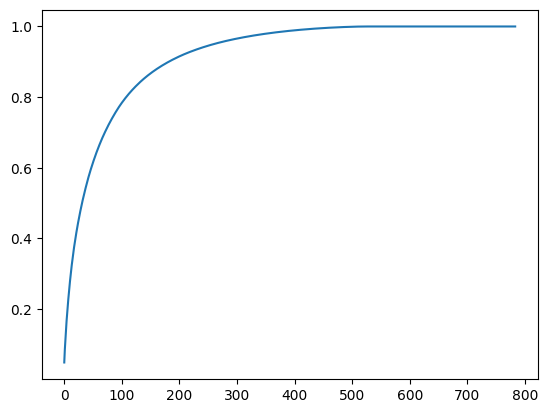

In [ ]:
plt.plot(np.cumsum(pca_new.explained_variance_ratio_))